In [111]:
%pip install --upgrade --force-reinstall --no-cache-dir numpy==1.26.4 scipy==1.11.4 scikit-learn==1.3.2
%pip install pandas
%pip install matplotlib
%pip install nltk
%pip install seaborn
%pip install wordcloud
import numpy as np
import pandas as pd

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
      --------------------------------------- 0.3/15.8 MB ? eta -:--:--
      --------------------------------------- 0.3/15.8 MB ? eta -:--:--
      --------------------------------------- 0.3/15.8 MB ? eta -:--:--
     - ------------------------------------- 0.5/15.8 MB 444.4 kB/s eta 0:00:35
     - ------------------------------------- 0.5/15.8 MB 444.4 kB/s eta 0:00:35
     - ------------------------------------- 0.8/15.8 MB 462.9 kB/s eta 0:00:33
     - ------------------------------------- 0.8/15.8 MB 462.9 kB/s eta 0:00:33
     - ------------------------------------- 0.8/15.8 MB 462.9 kB/s eta 0:00:33
     -- ----------

  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [19 lines of output]
      + c:\Python314\python.exe C:\Users\ASUS\AppData\Local\Temp\pip-install-99juti1y\numpy_5f5a2ca8c52549ff8ec201a4caeb385e\vendored-meson\meson\meson.py setup C:\Users\ASUS\AppData\Local\Temp\pip-install-99juti1y\numpy_5f5a2ca8c52549ff8ec201a4caeb385e C:\Users\ASUS\AppData\Local\Temp\pip-install-99juti1y\numpy_5f5a2ca8c52549ff8ec201a4caeb385e\.mesonpy-7mukk3uk -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\ASUS\AppData\Local\Temp\pip-install-99juti1y\numpy_5f5a2ca8c52549ff8ec201a4caeb385e\.mesonpy-7mukk3uk\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.99
      Source dir: C:\Users\ASUS\AppData\Local\Temp\pip-install-99juti1y\numpy_5f5a2ca8c52549ff8ec201a4caeb385e
      Build dir: C:\Users\ASUS\AppData\Local\Temp\pip-install-99juti1y\numpy_5f5a2ca8c52549ff8ec201a4caeb385e\.me

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [112]:
df=pd.read_csv('spam.csv',encoding='latin-1')

In [113]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3263,ham,I will send them to your email. Do you mind &...,NaN,NaN,NaN
600,ham,Mind blastin.. No more Tsunamis will occur fro...,NaN,NaN,NaN
4849,ham,Maybe you should find something else to do ins...,NaN,NaN,NaN
5143,ham,Hi darlin im on helens fone im gonna b up the ...,NaN,NaN,NaN
3813,ham,Can. Dunno wat to get 4 her...,NaN,NaN,NaN


In [114]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


In [115]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'], inplace=True)

In [116]:
df.size

11144

In [117]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   v1      5572 non-null   str  
 1   v2      5572 non-null   str  
dtypes: str(2)
memory usage: 541.4 KB


In [118]:
df.sample(5)

,v1,v2
1127,ham,"Height of \Oh shit....!!\"" situation: A guy th..."
3253,ham,I can make lasagna for you... vodka...
5195,ham,Darren was saying dat if u meeting da ge den w...
2795,ham,Tell your friends what you plan to do on Valen...
5157,ham,K k:) sms chat with me.


In [119]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
4624,ham,I'm on the bus. Love you
428,ham,7 at esplanade.. Do Ì_ mind giving me a lift c...
2532,ham,Yup ok...
3582,ham,I sent your maga that money yesterday oh.
507,ham,You should know now. So how's anthony. Are you...


In [120]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [121]:
df['target']=encoder.fit_transform(df['target'])

In [122]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [123]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [124]:
df.duplicated().sum()

np.int64(403)

In [125]:
df=df.drop_duplicates(keep='first')

In [126]:
df.duplicated().sum()

np.int64(0)

In [127]:
df.shape

(5169, 2)

In [128]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [129]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

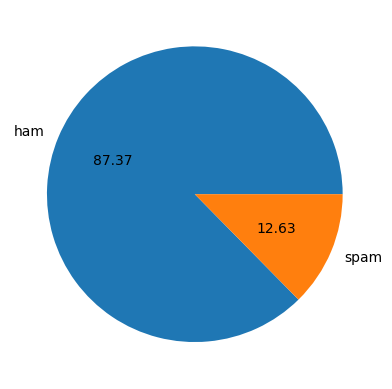

In [130]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [131]:
import nltk

In [132]:
df['length']=df['text'].apply(len)

In [133]:
df.head()

,target,text,length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [134]:
df['len_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [135]:
df.head()

,target,text,length,len_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [136]:
df['len_sentences']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [137]:
df.head()

,target,text,length,len_words,len_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [138]:
df[['length','len_words','len_sentences']].describe()

,length,len_words,len_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [139]:
df[df['target']==0][['length','len_words','len_sentences']].describe()#ham

,length,len_words,len_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [140]:
df[df['target']==1][['length','len_words','len_sentences']].describe()#spam

,length,len_words,len_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [141]:
import seaborn as sns

<Axes: xlabel='length', ylabel='Count'>

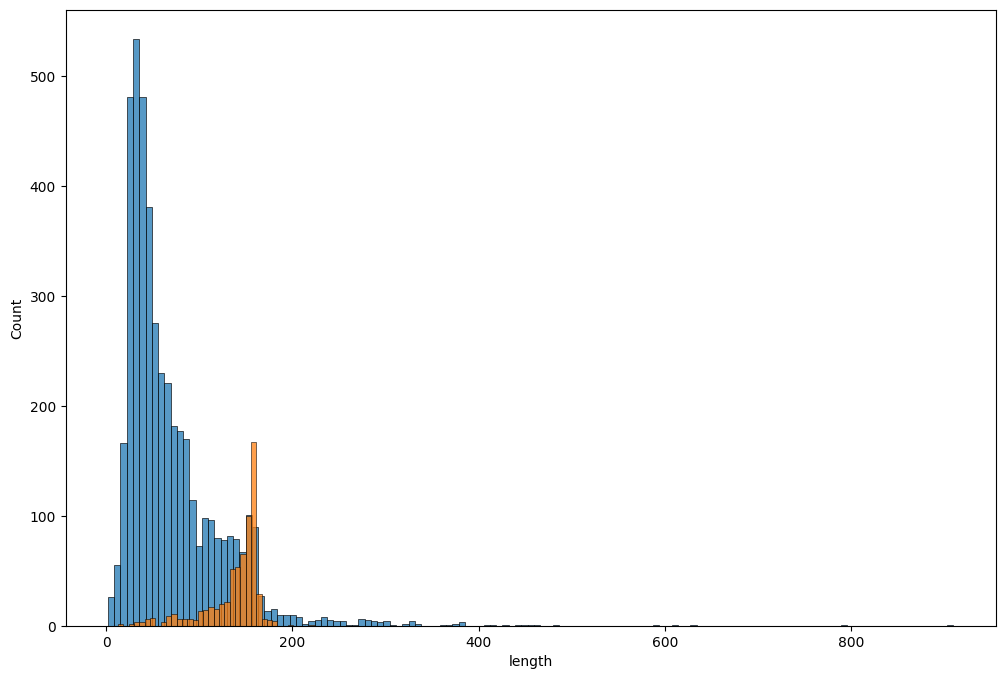

In [142]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['target']==0]['length'])
sns.histplot(df[df['target']==1]['length'])

<Axes: xlabel='len_words', ylabel='Count'>

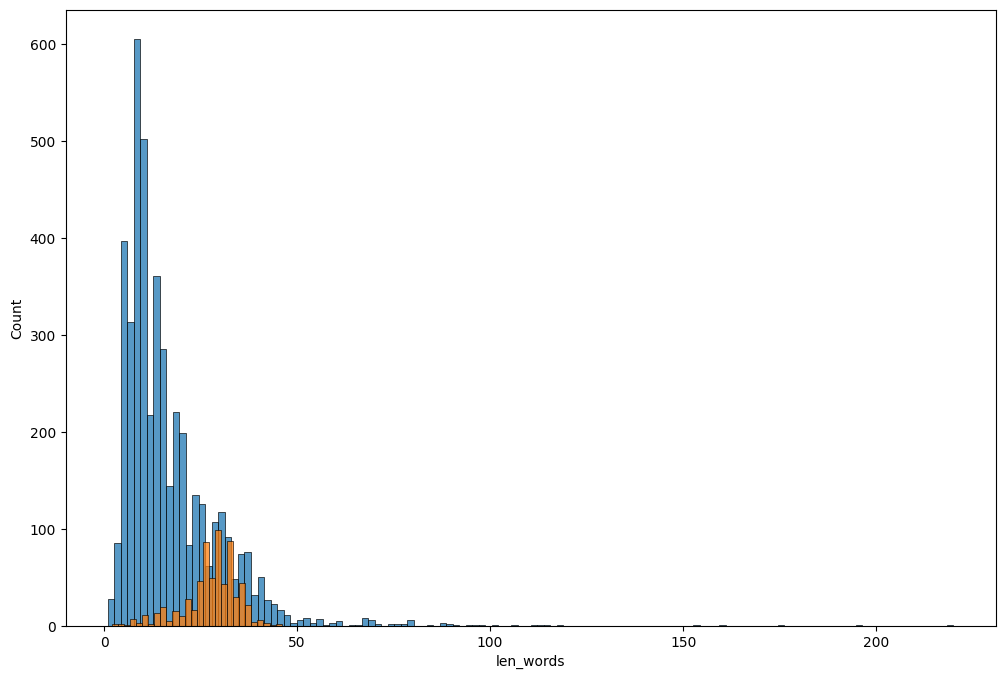

In [143]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['target']==0]['len_words'])
sns.histplot(df[df['target']==1]['len_words'])

<Axes: xlabel='len_sentences', ylabel='Count'>

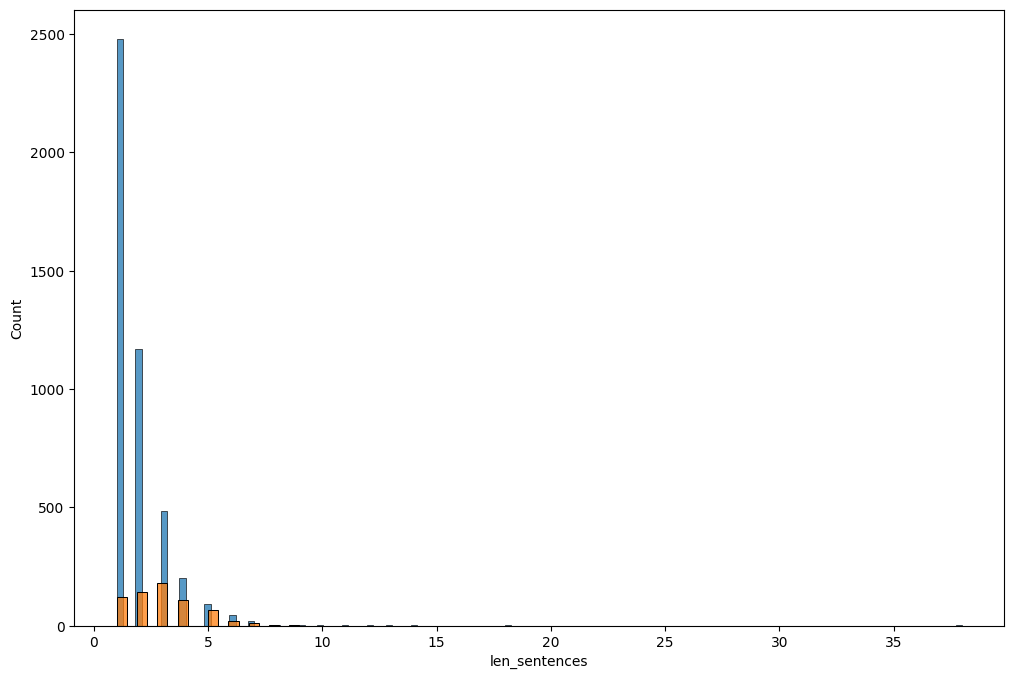

In [144]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['target']==0]['len_sentences'])
sns.histplot(df[df['target']==1]['len_sentences'])

<Axes: >

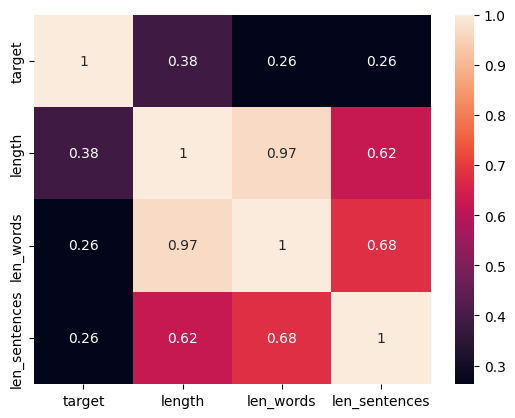

In [145]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [146]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [147]:
from nltk.stem import PorterStemmer
ps = PorterStemmer()
ps.stem('singing')

'sing'

In [148]:
import string

nltk.download('punkt', quiet=True)

def transform_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text)
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
    text=y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    
    text=y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
        
    return y

transform_text('Hi how are you mounteverest l?5')

['hi', 'mounteverest', 'l', '5']

In [149]:
transform_text('Were you born with a retarded brain?')

['born', 'retard', 'brain']

In [150]:
df['transformed_text']=df['text'].apply(transform_text)

In [151]:
from wordcloud import WordCloud
wc=WordCloud(width=50,height=50,min_font_size=10,background_color='white')

In [152]:
spam_wc = wc.generate(
	df[df['target'] == 1]['transformed_text']
	.apply(lambda tokens: " ".join(tokens))
	.str.cat(sep=" ")
)

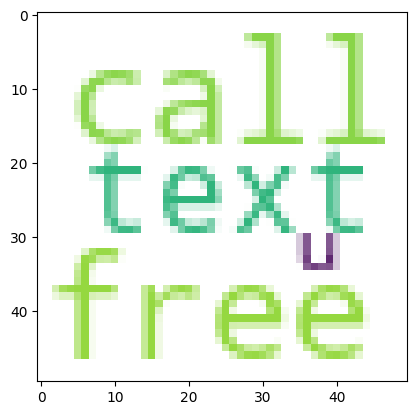

In [153]:
plt.imshow(spam_wc)

In [154]:
ham_wc = wc.generate(
	df[df['target'] == 0]['transformed_text']
	.apply(lambda tokens: " ".join(tokens))
	.str.cat(sep=" ")
)

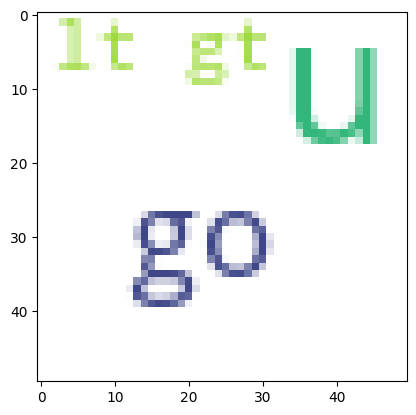

In [155]:
plt.imshow(ham_wc)

In [156]:
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    for words in msg:
        spam_corpus.append(words)

In [157]:
spam_corpus

['free',
 'entri',
 '2',
 'wkli',
 'comp',
 'win',
 'fa',
 'cup',
 'final',
 'tkt',
 '21st',
 'may',
 'text',
 'fa',
 '87121',
 'receiv',
 'entri',
 'question',
 'std',
 'txt',
 'rate',
 'c',
 'appli',
 '08452810075over18',
 'freemsg',
 'hey',
 'darl',
 '3',
 'week',
 'word',
 'back',
 'like',
 'fun',
 'still',
 'tb',
 'ok',
 'xxx',
 'std',
 'chg',
 'send',
 'rcv',
 'winner',
 'valu',
 'network',
 'custom',
 'select',
 'receivea',
 'prize',
 'reward',
 'claim',
 'call',
 'claim',
 'code',
 'kl341',
 'valid',
 '12',
 'hour',
 'mobil',
 '11',
 'month',
 'u',
 'r',
 'entitl',
 'updat',
 'latest',
 'colour',
 'mobil',
 'camera',
 'free',
 'call',
 'mobil',
 'updat',
 'co',
 'free',
 '08002986030',
 'six',
 'chanc',
 'win',
 'cash',
 '100',
 'pound',
 'txt',
 'csh11',
 'send',
 'cost',
 '6day',
 'tsandc',
 'appli',
 'repli',
 'hl',
 '4',
 'info',
 'urgent',
 '1',
 'week',
 'free',
 'membership',
 'prize',
 'jackpot',
 'txt',
 'word',
 'claim',
 '81010',
 'c',
 'lccltd',
 'pobox',
 '4403ldnw

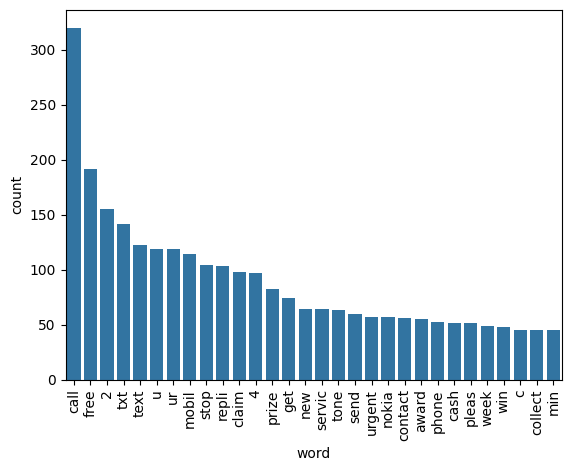

In [158]:
from collections import Counter
top_spam_words = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])
sns.barplot(data=top_spam_words, x='word', y='count')
plt.xticks(rotation='vertical')
plt.show()

In [159]:
ham_corpus=[]
for msg in df[df['target']==0]['transformed_text'].tolist():
    for words in msg:
        ham_corpus.append(words)

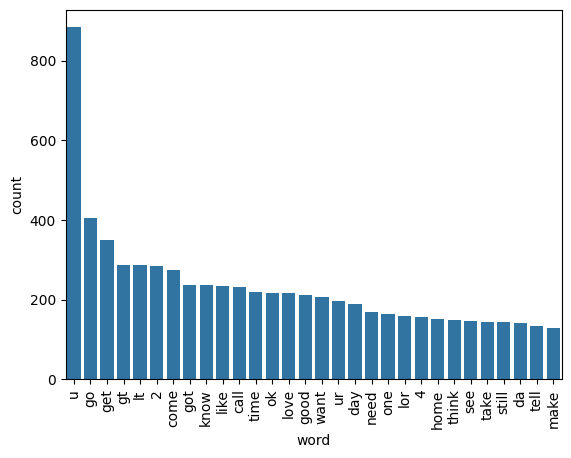

In [160]:
from collections import Counter
top_ham_words = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['word', 'count'])
sns.barplot(data=top_ham_words, x='word', y='count')
plt.xticks(rotation='vertical')
plt.show()

In [161]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer()

In [162]:
X = cv.fit_transform(
	df['transformed_text'].apply(lambda tokens: " ".join(tokens))
).toarray()

In [163]:
X.shape

(5169, 6708)

In [164]:
y=df['target'].values
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [165]:
from sklearn.model_selection import train_test_split

In [166]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [167]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [168]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print("GaussianNB Accuracy:", accuracy_score(y_test, y_pred1))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred1))
print("Precision Score:", precision_score(y_test, y_pred1))

GaussianNB Accuracy: 0.8800773694390716
Confusion Matrix:
 [[792 104]
 [ 20 118]]
Precision Score: 0.5315315315315315


In [169]:
mnb.fit(X_train, y_train)
y_pred2= mnb.predict(X_test)
print("GaussianNB Accuracy:", accuracy_score(y_test, y_pred2))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred2))
print("Precision Score:", precision_score(y_test, y_pred2))

GaussianNB Accuracy: 0.9642166344294004
Confusion Matrix:
 [[871  25]
 [ 12 126]]
Precision Score: 0.8344370860927153


In [170]:
bnb.fit(X_train, y_train)
y_pred3=bnb.predict(X_test)
print("GaussianNB Accuracy:", accuracy_score(y_test, y_pred3))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred3))
print("Precision Score:", precision_score(y_test, y_pred3))

GaussianNB Accuracy: 0.9700193423597679
Confusion Matrix:
 [[893   3]
 [ 28 110]]
Precision Score: 0.9734513274336283


In [171]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=3000)

In [172]:
type(tfidf)

sklearn.feature_extraction.text.TfidfVectorizer

In [173]:
X1=tfidf.fit_transform(df['transformed_text'].apply(lambda tokens:" ".join(tokens))).toarray()

In [174]:
X1_train,X1_test,y_train,y_test=train_test_split(X1,y,test_size=0.2,random_state=2)

In [175]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [176]:
gnb.fit(X1_train, y_train)
y_pred11= gnb.predict(X1_test)
print("GaussianNB Accuracy:", accuracy_score(y_test, y_pred11))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred11))
print("Precision Score:", precision_score(y_test, y_pred11))

GaussianNB Accuracy: 0.874274661508704
Confusion Matrix:
 [[790 106]
 [ 24 114]]
Precision Score: 0.5181818181818182


In [177]:
mnb.fit(X1_train, y_train)
y_pred21= mnb.predict(X1_test)
print("GaussianNB Accuracy:", accuracy_score(y_test, y_pred21))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred21))
print("Precision Score:", precision_score(y_test, y_pred21))

GaussianNB Accuracy: 0.9709864603481625
Confusion Matrix:
 [[896   0]
 [ 30 108]]
Precision Score: 1.0


In [178]:
bnb.fit(X1_train, y_train)
y_pred31=bnb.predict(X1_test)
print("GaussianNB Accuracy:", accuracy_score(y_test, y_pred31))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred31))
print("Precision Score:", precision_score(y_test, y_pred31))

GaussianNB Accuracy: 0.9835589941972921
Confusion Matrix:
 [[895   1]
 [ 16 122]]
Precision Score: 0.991869918699187


In [179]:
# TFIDF+MNB -> best results
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [180]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [181]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [182]:
def train_classifier(clf,X1_train,y_train,X1_test,y_test):
    clf.fit(X1_train,y_train)
    y_pred = clf.predict(X1_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [183]:
train_classifier(knc,X1_train,y_train,X1_test,y_test)

(0.9052224371373307, 1.0)

In [184]:
train_classifier(svc,X1_train,y_train,X1_test,y_test)

(0.9758220502901354, 0.9747899159663865)

In [185]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X1_train,y_train,X1_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9758220502901354
Precision -  0.9747899159663865
For  KN
Accuracy -  0.9052224371373307
Precision -  1.0
For  NB
Accuracy -  0.9709864603481625
Precision -  1.0
For  DT
Accuracy -  0.9313346228239845
Precision -  0.8383838383838383
For  LR
Accuracy -  0.9555125725338491
Precision -  0.96


C:\Users\ASUS\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\ASUS\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For  RF
Accuracy -  0.9738878143133463
Precision -  0.9826086956521739
For  AdaBoost
Accuracy -  0.9216634429400387
Precision -  0.8202247191011236
For  BgC
Accuracy -  0.9584139264990329
Precision -  0.8682170542635659
For  ETC
Accuracy -  0.9748549323017408
Precision -  0.9745762711864406
For  GBDT
Accuracy -  0.9506769825918762
Precision -  0.9306930693069307
For  xgb
Accuracy -  0.9680851063829787
Precision -  0.9487179487179487


In [186]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.905222,1.000000
2,NB,0.970986,1.000000
5,RF,0.973888,0.982609
0,SVC,0.975822,0.974790
8,ETC,0.974855,0.974576
4,LR,0.955513,0.960000
10,xgb,0.968085,0.948718
9,GBDT,0.950677,0.930693
7,BgC,0.958414,0.868217
3,DT,0.931335,0.838384


In [187]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.905222
1,NB,Accuracy,0.970986
2,RF,Accuracy,0.973888
3,SVC,Accuracy,0.975822
4,ETC,Accuracy,0.974855
5,LR,Accuracy,0.955513
6,xgb,Accuracy,0.968085
7,GBDT,Accuracy,0.950677
8,BgC,Accuracy,0.958414
9,DT,Accuracy,0.931335


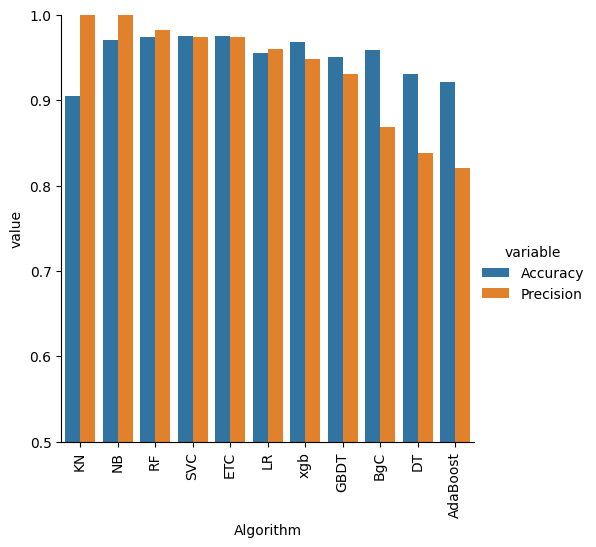

In [188]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [189]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.905222
1,NB,Accuracy,0.970986
2,RF,Accuracy,0.973888
3,SVC,Accuracy,0.975822
4,ETC,Accuracy,0.974855
5,LR,Accuracy,0.955513
6,xgb,Accuracy,0.968085
7,GBDT,Accuracy,0.950677
8,BgC,Accuracy,0.958414
9,DT,Accuracy,0.931335


In [190]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.905222,1.000000
2,NB,0.970986,1.000000
5,RF,0.973888,0.982609
0,SVC,0.975822,0.974790
8,ETC,0.974855,0.974576
4,LR,0.955513,0.960000
10,xgb,0.968085,0.948718
9,GBDT,0.950677,0.930693
7,BgC,0.958414,0.868217
3,DT,0.931335,0.838384


In [191]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))